Linear Kernel Accuracy: 0.89


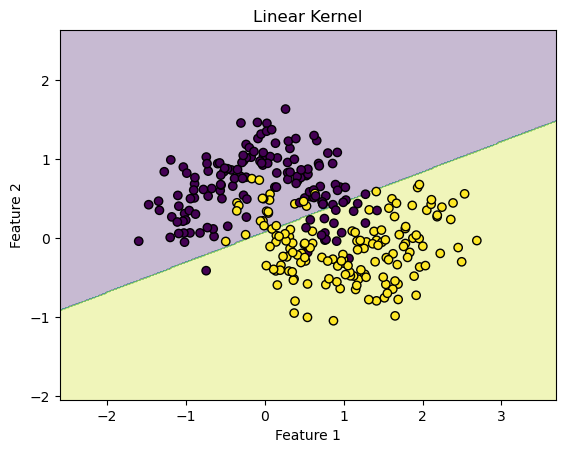

Polynomial Kernel Accuracy: 0.89


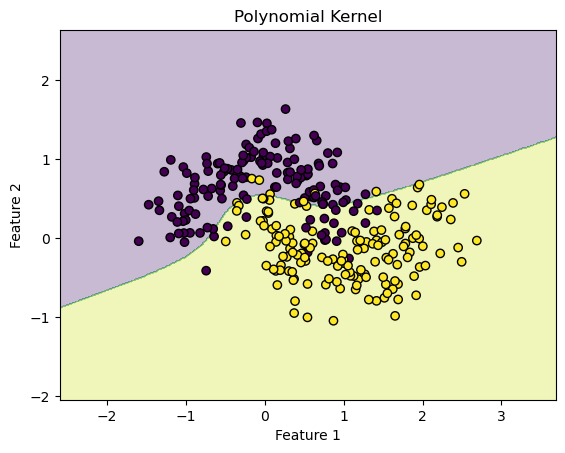

RBF Kernel Accuracy: 0.91


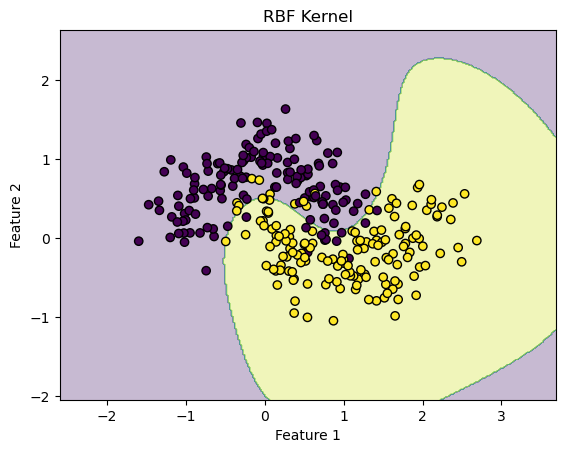

Low gamma: 0.88


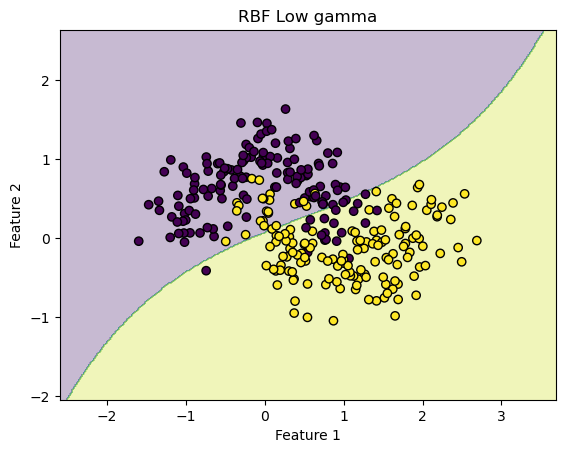

High gamma: 0.94


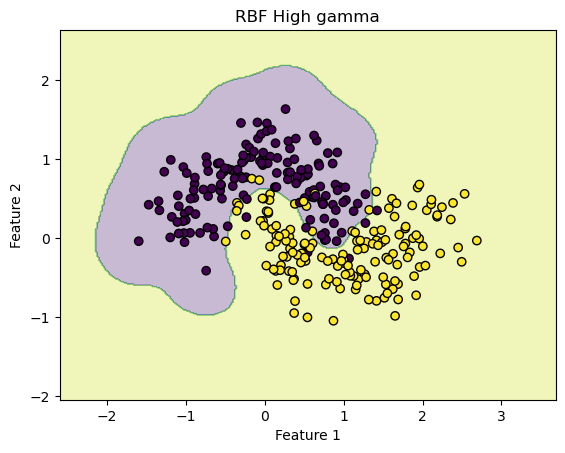

Low C: 0.91


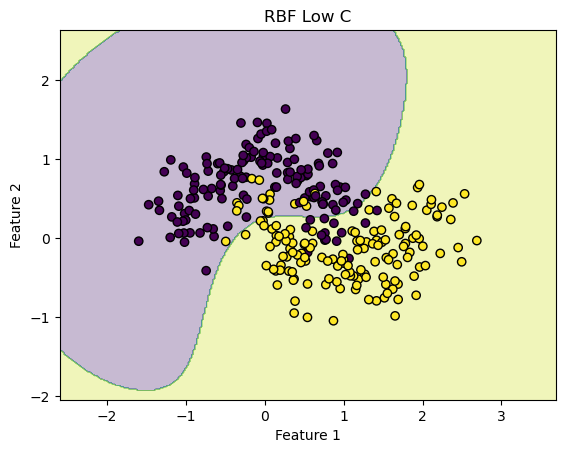

High C: 0.94


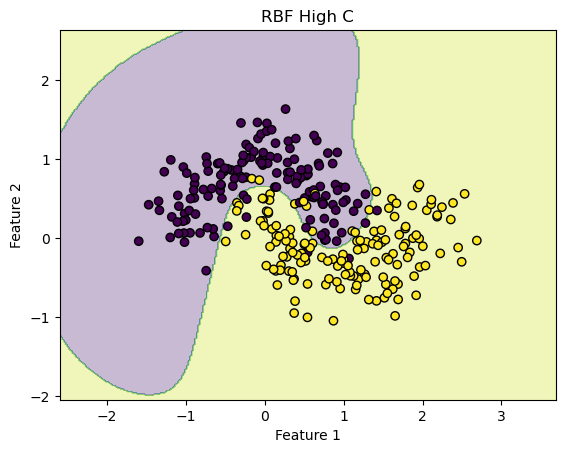

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Generate dataset
X, y = datasets.make_moons(n_samples=300, noise=0.25, random_state=42)

# Train-test split (important for marks)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Models
models = {
    "Linear": SVC(kernel="linear"),
    "Polynomial": SVC(kernel="poly", degree=3),
    "RBF": SVC(kernel="rbf", gamma=1)
}

# Improved plotting
def plot_decision_boundary(model, X, y, title):
    model.fit(X, y)
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Train and evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Kernel Accuracy: {acc:.2f}")
    plot_decision_boundary(model, X, y, name + " Kernel")

# Hyperparameter tuning (RBF)
configs = [
    ("Low gamma", SVC(kernel="rbf", gamma=0.1)),
    ("High gamma", SVC(kernel="rbf", gamma=10)),
    ("Low C", SVC(kernel="rbf", C=0.1)),
    ("High C", SVC(kernel="rbf", C=100))
]

for name, model in configs:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.2f}")
    plot_decision_boundary(model, X, y, "RBF " + name)